(complex_and_trig)=
```{raw} html
<div id="qe-notebook-header" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

```{index} single: python
```

# Complex Numbers and Trigonometry

## Overview

This lecture introduces some elementary mathematics and trigonometry.

Useful and interesting in its own right, these concepts reap substantial rewards when studying dynamics generated
by linear difference equations or linear differential equations.

For example, these tools are keys to understanding outcomes attained by Paul
Samuelson (1939) {cite}`Samuelson1939` in his classic paper on interactions
between the investment accelerator and the Keynesian consumption function, our
topic in the lecture {doc}`Samuelson Multiplier Accelerator <dynam:samuelson>`.

In addition to providing foundations for Samuelson's work and extensions of
it, this lecture can be read as a stand-alone quick reminder of key results
from elementary high school trigonometry.

So let's dive in.

### Complex Numbers

A complex number has a **real part** $x$ and a purely **imaginary part** $y$.

The Euclidean, polar, and trigonometric forms of a complex number $z$ are:

$$
z = x + iy = re^{i\theta} = r(\cos{\theta} + i \sin{\theta})
$$

The second equality above is known as **Euler's formula**

- [Euler](https://en.wikipedia.org/wiki/Leonhard_Euler) contributed many other formulas too!

The complex conjugate $\bar z$ of $z$ is defined as

$$
\bar z = x - iy = r e^{-i \theta} = r (\cos{\theta} - i \sin{\theta} )
$$

The value $x$ is the **real** part of $z$ and $y$ is the
**imaginary** part of $z$.

The symbol $| z |$ = $\sqrt{\bar{z}\cdot z} = r$ represents the **modulus** of $z$.

The value $r$ is the Euclidean distance of vector $(x,y)$ from the
origin:

$$
r = |z| = \sqrt{x^2 + y^2}
$$

The value $\theta$ is the angle of $(x,y)$ with respect to the real axis.

Evidently, the tangent of $\theta$ is $\left(\frac{y}{x}\right)$.

Therefore,

$$
\theta = \tan^{-1} \Big( \frac{y}{x} \Big)
$$

Three elementary trigonometric functions are

$$
\cos{\theta} = \frac{x}{r} = \frac{e^{i\theta} + e^{-i\theta}}{2} , \quad
\sin{\theta} = \frac{y}{r} = \frac{e^{i\theta} - e^{-i\theta}}{2i} , \quad
\tan{\theta} = \frac{y}{x}
$$

We'll need the following imports:

In [1]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 5)  #set default figure size
import numpy as np
from sympy import (Symbol, symbols, Eq, nsolve, sqrt, cos, sin, simplify,
                  init_printing, integrate)

### An Example

```{prf:example}
:label: ct_ex_com

Consider the complex number $z = 1 + \sqrt{3} i$.

For $z = 1 + \sqrt{3} i$, $x = 1$, $y = \sqrt{3}$.

It follows that $r = 2$ and
$\theta = \tan^{-1}(\sqrt{3}) = \frac{\pi}{3} = 60^o$.
```

Let's use Python to plot the trigonometric form of the complex number
$z = 1 + \sqrt{3} i$.

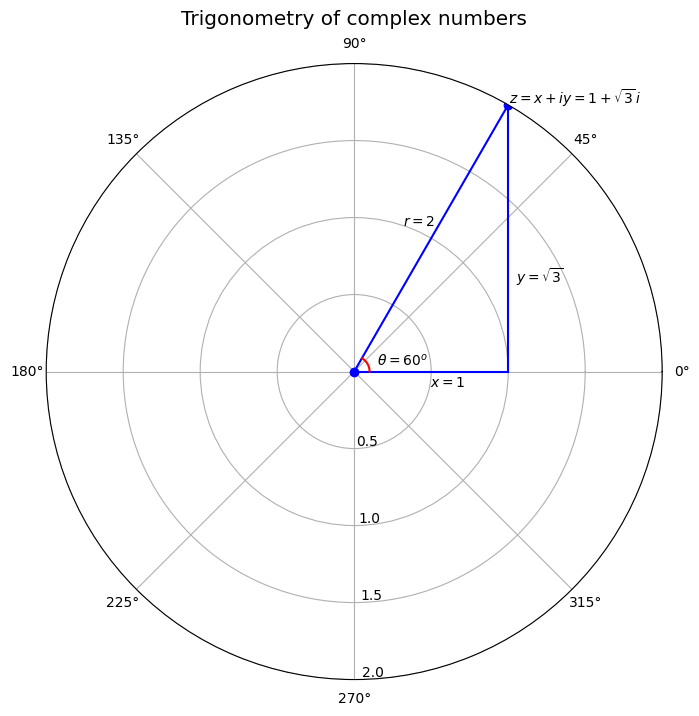

In [2]:
# Abbreviate useful values and functions
π = np.pi


# Set parameters
r = 2
θ = π/3
x = r * np.cos(θ)
x_range = np.linspace(0, x, 1000)
θ_range = np.linspace(0, θ, 1000)

# Plot
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')

ax.plot((0, θ), (0, r), marker='o', color='b')          # Plot r
ax.plot(np.zeros(x_range.shape), x_range, color='b')       # Plot x
ax.plot(θ_range, x / np.cos(θ_range), color='b')        # Plot y
ax.plot(θ_range, np.full(θ_range.shape, 0.1), color='r')  # Plot θ

ax.margins(0) # Let the plot starts at origin

ax.set_title("Trigonometry of complex numbers", va='bottom',
    fontsize='x-large')

ax.set_rmax(2)
ax.set_rticks((0.5, 1, 1.5, 2))  # Less radial ticks
ax.set_rlabel_position(-88.5)    # Get radial labels away from plotted line

ax.text(θ, r+0.01 , r'$z = x + iy = 1 + \sqrt{3}\, i$')   # Label z
ax.text(θ+0.2, 1 , '$r = 2$')                             # Label r
ax.text(0-0.2, 0.5, '$x = 1$')                            # Label x
ax.text(0.5, 1.2, r'$y = \sqrt{3}$')                      # Label y
ax.text(0.25, 0.15, r'$\theta = 60^o$')                   # Label θ

ax.grid(True)
plt.show()

## De Moivre's Theorem

de Moivre's theorem states that:

$$
(r(\cos{\theta} + i \sin{\theta}))^n =
r^n e^{in\theta} =
r^n(\cos{n\theta} + i \sin{n\theta})
$$

To prove de Moivre's theorem, note that

$$
(r(\cos{\theta} + i \sin{\theta}))^n = \big( re^{i\theta} \big)^n
$$

and compute.

## Applications of de Moivre's Theorem

### Example 1

We can use de Moivre's theorem to show that
$r = \sqrt{x^2 + y^2}$.

We have

$$
\begin{aligned}
1 &= e^{i\theta} e^{-i\theta} \\
&= (\cos{\theta} + i \sin{\theta})(\cos{(\text{-}\theta)} + i \sin{(\text{-}\theta)}) \\
&= (\cos{\theta} + i \sin{\theta})(\cos{\theta} - i \sin{\theta}) \\
&= \cos^2{\theta} + \sin^2{\theta} \\
&= \frac{x^2}{r^2} + \frac{y^2}{r^2}
\end{aligned}
$$

and thus

$$
x^2 + y^2 = r^2
$$

We recognize this as a theorem of **Pythagoras**.

### Example 2

Let $z = re^{i\theta}$ and $\bar{z} = re^{-i\theta}$ so that $\bar{z}$ is the **complex conjugate** of $z$.

$(z, \bar z)$ form a **complex conjugate pair** of complex numbers.

Let $a = pe^{i\omega}$ and $\bar{a} = pe^{-i\omega}$ be
another complex conjugate pair.

For each element of a sequence of integers $n = 0, 1, 2, \ldots, $.

To do so, we can apply de Moivre's formula.

Thus,

$$
\begin{aligned}
x_n &= az^n + \bar{a}\bar{z}^n \\
&= p e^{i\omega} (re^{i\theta})^n + p e^{-i\omega} (re^{-i\theta})^n \\
&= pr^n e^{i (\omega + n\theta)} + pr^n e^{-i (\omega + n\theta)} \\
&= pr^n [\cos{(\omega + n\theta)} + i \sin{(\omega + n\theta)} +
         \cos{(\omega + n\theta)} - i \sin{(\omega + n\theta)}] \\
&= 2 pr^n \cos{(\omega + n\theta)}
\end{aligned}
$$

### Example 3

This example provides  machinery that is at the heard of Samuelson's analysis of his multiplier-accelerator model {cite}`Samuelson1939`.

Thus, consider a **second-order linear difference equation**

$$
x_{n+2} = c_1 x_{n+1} + c_2 x_n
$$

whose **characteristic polynomial** is

$$
z^2 - c_1 z - c_2 = 0
$$

or

$$
(z^2 - c_1 z - c_2 ) = (z - z_1)(z- z_2) = 0
$$

has roots $z_1, z_1$.

A **solution**  is a sequence $\{x_n\}_{n=0}^\infty$ that satisfies
the difference equation.

Under the following circumstances, we can apply our example 2 formula to
solve the difference equation

- the roots $z_1, z_2$ of the characteristic polynomial of the
  difference equation form a complex conjugate pair
- the values $x_0, x_1$ are given initial conditions

To solve the difference equation, recall from example 2 that

$$
x_n = 2 pr^n \cos{(\omega + n\theta)}
$$

where $\omega, p$ are coefficients to be determined from
information encoded in the initial conditions $x_1, x_0$.

Since
$x_0 = 2 p \cos{\omega}$ and $x_1 = 2 pr \cos{(\omega + \theta)}$
the ratio of $x_1$ to $x_0$ is

$$
\frac{x_1}{x_0} = \frac{r \cos{(\omega + \theta)}}{\cos{\omega}}
$$

We can solve this equation for $\omega$ then solve for $p$ using $x_0 = 2 pr^0 \cos{(\omega + n\theta)}$.

With the `sympy` package in Python, we are able to solve and plot the
dynamics of $x_n$ given different values of $n$.

In this example, we set the initial values: - $r = 0.9$ -
$\theta = \frac{1}{4}\pi$ - $x_0 = 4$ -
$x_1 = r \cdot 2\sqrt{2} = 1.8 \sqrt{2}$.

We first numerically solve for $\omega$ and $p$ using
`nsolve` in the `sympy` package based on the above initial
condition:

In [3]:
# Set parameters
r = 0.9
θ = π/4
x0 = 4
x1 = 2 * r * sqrt(2)

# Define symbols to be calculated
ω, p = symbols('ω p', real=True)

# Solve for ω
## Note: we choose the solution near 0
eq1 = Eq(x1/x0 - r * cos(ω+θ) / cos(ω), 0)
ω = nsolve(eq1, ω, 0)
ω = float(ω)
print(f'ω = {ω:1.3f}')

# Solve for p
eq2 = Eq(x0 - 2 * p * cos(ω), 0)
p = nsolve(eq2, p, 0)
p = float(p)
print(f'p = {p:1.3f}')

ω = 0.000
p = 2.000


Using the code above, we compute that
$\omega = 0$ and $p = 2$.

Then we plug in the values we solve for $\omega$ and $p$
and plot the dynamic.

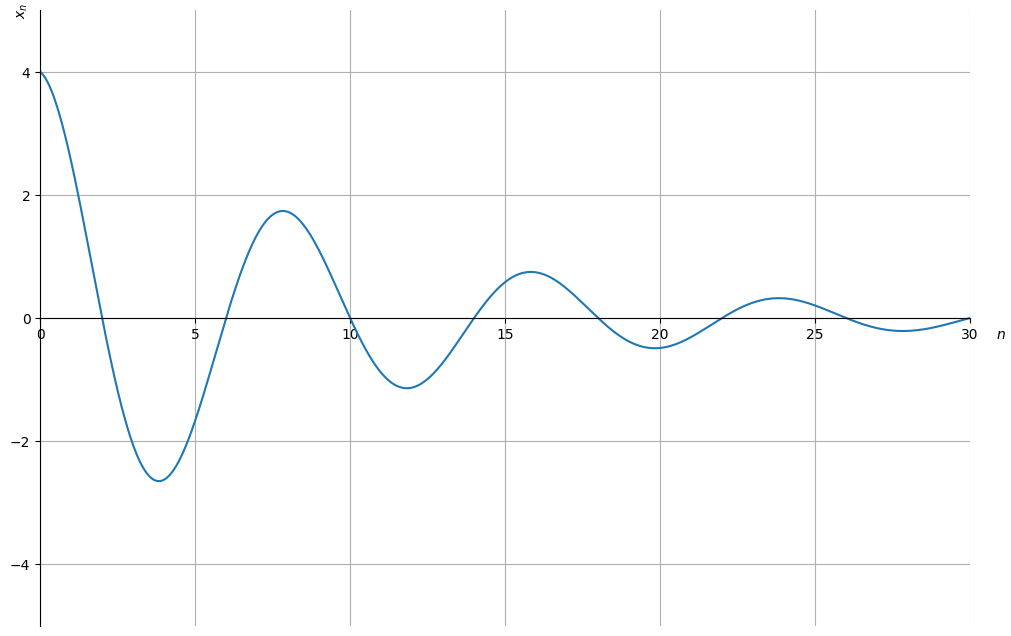

In [4]:
# Define range of n
max_n = 30
n = np.arange(0, max_n+1, 0.01)

# Define x_n
x = lambda n: 2 * p * r**n * np.cos(ω + n * θ)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(n, x(n))
ax.set(xlim=(0, max_n), ylim=(-5, 5), xlabel='$n$', ylabel='$x_n$')

# Set x-axis in the middle of the plot
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ticklab = ax.xaxis.get_ticklabels()[0] # Set x-label position
trans = ticklab.get_transform()
ax.xaxis.set_label_coords(31, 0, transform=trans)

ticklab = ax.yaxis.get_ticklabels()[0] # Set y-label position
trans = ticklab.get_transform()
ax.yaxis.set_label_coords(0, 5, transform=trans)

ax.grid()
plt.show()

### Trigonometric Identities

We can obtain a complete suite of trigonometric identities by
appropriately manipulating polar forms of complex numbers.

We'll get many of them by deducing implications of the equality

$$
e^{i(\omega + \theta)} = e^{i\omega} e^{i\theta}
$$

For example, we'll calculate identities for

$\cos{(\omega + \theta)}$ and $\sin{(\omega + \theta)}$.

Using the sine and cosine formulas presented at the beginning of this
lecture, we have:

$$
\begin{aligned}
\cos{(\omega + \theta)} = \frac{e^{i(\omega + \theta)} + e^{-i(\omega + \theta)}}{2} \\
\sin{(\omega + \theta)} = \frac{e^{i(\omega + \theta)} - e^{-i(\omega + \theta)}}{2i}
\end{aligned}
$$

We can also obtain the trigonometric identities as follows:

$$
\begin{aligned}
\cos{(\omega + \theta)} + i \sin{(\omega + \theta)}
&= e^{i(\omega + \theta)} \\
&= e^{i\omega} e^{i\theta} \\
&= (\cos{\omega} + i \sin{\omega})(\cos{\theta} + i \sin{\theta}) \\
&= (\cos{\omega}\cos{\theta} - \sin{\omega}\sin{\theta}) +
i (\cos{\omega}\sin{\theta} + \sin{\omega}\cos{\theta})
\end{aligned}
$$

Since both real and imaginary parts of the above formula should be
equal, we get:

$$
\begin{aligned}
\cos{(\omega + \theta)} = \cos{\omega}\cos{\theta} - \sin{\omega}\sin{\theta} \\
\sin{(\omega + \theta)} = \cos{\omega}\sin{\theta} + \sin{\omega}\cos{\theta}
\end{aligned}
$$

The equations above are also known as the **angle sum identities**. We
can verify the equations using the `simplify` function in the
`sympy` package:

In [5]:
# Define symbols
ω, θ = symbols('ω θ', real=True)

# Verify
print("cos(ω)cos(θ) - sin(ω)sin(θ) =",
    simplify(cos(ω)*cos(θ) - sin(ω) * sin(θ)))
print("cos(ω)sin(θ) + sin(ω)cos(θ) =",
    simplify(cos(ω)*sin(θ) + sin(ω) * cos(θ)))

cos(ω)cos(θ) - sin(ω)sin(θ) = cos(θ + ω)
cos(ω)sin(θ) + sin(ω)cos(θ) = sin(θ + ω)


### Trigonometric Integrals

We can also compute the trigonometric integrals using polar forms of
complex numbers.

For example, we want to solve the following integral:

$$
\int_{-\pi}^{\pi} \cos(\omega) \sin(\omega) \, d\omega
$$

Using Euler's formula, we have:

$$
\begin{aligned}
\int \cos(\omega) \sin(\omega) \, d\omega
&=
\int
\frac{(e^{i\omega} + e^{-i\omega})}{2}
\frac{(e^{i\omega} - e^{-i\omega})}{2i}
\, d\omega  \\
&=
\frac{1}{4i}
\int
e^{2i\omega} - e^{-2i\omega}
\, d\omega  \\
&=
\frac{1}{4i}
\bigg( \frac{-i}{2} e^{2i\omega} - \frac{i}{2} e^{-2i\omega} + C_1 \bigg) \\
&=
-\frac{1}{8}
\bigg[ \bigg(e^{i\omega}\bigg)^2 + \bigg(e^{-i\omega}\bigg)^2 - 2 \bigg] + C_2 \\
&=
-\frac{1}{8}  (e^{i\omega} - e^{-i\omega})^2  + C_2 \\
&=
\frac{1}{2} \bigg( \frac{e^{i\omega} - e^{-i\omega}}{2i} \bigg)^2 + C_2 \\
&= \frac{1}{2} \sin^2(\omega) + C_2
\end{aligned}
$$

and thus:

$$
\int_{-\pi}^{\pi} \cos(\omega) \sin(\omega) \, d\omega =
\frac{1}{2}\sin^2(\pi) - \frac{1}{2}\sin^2(-\pi) = 0
$$

We can verify the analytical as well as numerical results using
`integrate` in the `sympy` package:

In [6]:
# Set initial printing
init_printing(use_latex="mathjax")

ω = Symbol('ω')
print('The analytical solution for integral of cos(ω)sin(ω) is:')
integrate(cos(ω) * sin(ω), ω)

The analytical solution for integral of cos(ω)sin(ω) is:


   2   
sin (ω)
───────
   2   

In [7]:
print('The numerical solution for the integral of cos(ω)sin(ω) \
from -π to π is:')
integrate(cos(ω) * sin(ω), (ω, -π, π))

The numerical solution for the integral of cos(ω)sin(ω) from -π to π is:


0

### Exercises

```{exercise}
:label: complex_ex1

We invite the reader to verify analytically and with the `sympy` package the following two equalities:

$$
\int_{-\pi}^{\pi} \cos (\omega)^2 \, d\omega = \pi
$$

$$
\int_{-\pi}^{\pi} \sin (\omega)^2 \, d\omega = \pi
$$
```

```{solution-start} complex_ex1
:class: dropdown
```

Let's import symbolic $\pi$ from `sympy`

In [8]:
# Import symbolic π from sympy
from sympy import pi

In [9]:
print('The analytical solution for the integral of cos(ω)**2 \
from -π to π is:')

integrate(cos(ω)**2, (ω, -pi, pi))

The analytical solution for the integral of cos(ω)**2 from -π to π is:


π

In [10]:
print('The analytical solution for the integral of sin(ω)**2 \
from -π to π is:')

integrate(sin(ω)**2, (ω, -pi, pi))

The analytical solution for the integral of sin(ω)**2 from -π to π is:


π

```{solution-end}
```